# COVID-19 in China — Regression, Classification and Clustering

Using the daily confirmed COVID-19 cases for Chinese provinces, this project covers four parts:

1. **Data preparation** - turn Beijing's daily series into a sliding-window regression dataset.
2. **Regression** - predict the 6th day from the previous five (linear and LASSO).
3. **Classification** - predict whether the next day goes up, down or stays stable (logistic regression).
4. **Clustering** - test whether geographically near provinces show similar case counts (k-means).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, accuracy_score, adjusted_rand_score
from sklearn.cluster import KMeans

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

## Part 1 - Data preparation

Select Beijing and slide a window of six days across its series: the first five days become the
predictors `x1`..`x5` and the sixth day becomes the target `y`.

In [2]:
df = pd.read_csv('daily_confirmed_cases.csv', index_col=0)
beijing = df[df['Province'] == 'Beijing'].drop(columns='Province').values.flatten()

windows = [beijing[i:i + 6] for i in range(len(beijing) - 5)]
reg = pd.DataFrame(windows, columns=['x1', 'x2', 'x3', 'x4', 'x5', 'y'])
reg.to_csv('Beijing_covid19_regression.csv', index=False)
print('Regression dataset:', reg.shape)
reg.head()

Regression dataset: (67, 6)


,x1,x2,x3,x4,x5,y
0,14,8,14,5,27,12
1,8,14,5,27,12,11
2,14,5,27,12,11,20
3,5,27,12,11,20,3
4,27,12,11,20,3,25


## Part 2 - Regression

Can the confirmed cases of the last five days predict the sixth day? Split the data, fit a linear
model and a LASSO model, and measure the error (MSE).

In [3]:
X = reg[['x1', 'x2', 'x3', 'x4', 'x5']].values
y = reg['y'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (46, 5) | Test: (21, 5)


### Linear regression

In [4]:
lin = LinearRegression().fit(X_train, y_train)
lin_mse = mean_squared_error(y_test, lin.predict(X_test))
print('Linear regression - test MSE:', round(lin_mse, 4))

Linear regression - test MSE: 36.6749


### LASSO regression

In [5]:
lasso = Lasso(alpha=1.0, max_iter=10000).fit(X_train, y_train)
lasso_mse = mean_squared_error(y_test, lasso.predict(X_test))
print('LASSO (alpha=1) - test MSE:', round(lasso_mse, 4))
print('LASSO coefficients:', np.round(lasso.coef_, 4))

LASSO (alpha=1) - test MSE: 33.6278
LASSO coefficients: [ 0.1981 -0.3055  0.0956  0.3518  0.4192]


### Effect of the LASSO `alpha` parameter

As `alpha` grows the coefficients shrink toward zero; the model then just predicts the mean and the
error stops changing.

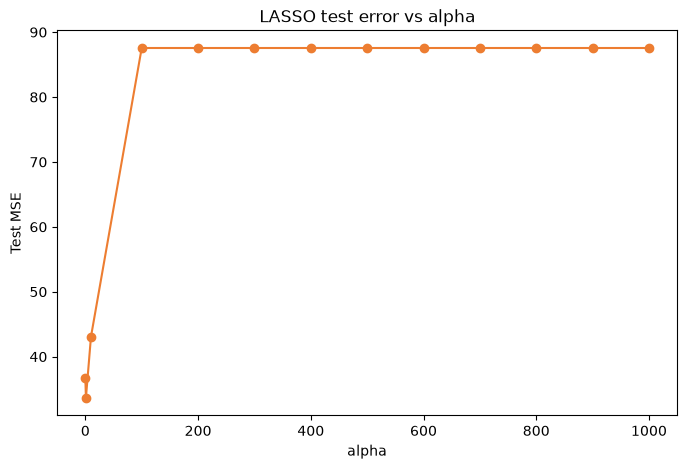

  alpha =    0:  test MSE = 36.6749
  alpha =    1:  test MSE = 33.6278
  alpha =   10:  test MSE = 43.0830
  alpha =  100:  test MSE = 87.5579
  alpha =  200:  test MSE = 87.5579
  alpha =  300:  test MSE = 87.5579
  alpha =  400:  test MSE = 87.5579
  alpha =  500:  test MSE = 87.5579
  alpha =  600:  test MSE = 87.5579
  alpha =  700:  test MSE = 87.5579
  alpha =  800:  test MSE = 87.5579
  alpha =  900:  test MSE = 87.5579
  alpha = 1000:  test MSE = 87.5579


In [6]:
alphas = [0, 1, 10, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
mse_by_alpha = []
for a in alphas:
    model = LinearRegression() if a == 0 else Lasso(alpha=a, max_iter=10000)
    model.fit(X_train, y_train)
    mse_by_alpha.append(mean_squared_error(y_test, model.predict(X_test)))

plt.figure(figsize=(8, 5))
plt.plot(alphas, mse_by_alpha, marker='o', color='#ED7D31')
plt.xlabel('alpha'); plt.ylabel('Test MSE')
plt.title('LASSO test error vs alpha')
plt.show()

for a, m in zip(alphas, mse_by_alpha):
    print(f'  alpha = {a:>4}:  test MSE = {m:.4f}')

## Part 3 - Classification

Label each window by how the sixth day moves relative to the fifth: `goup` if `y - x5 > 0`,
`godown` if `< 0`, `stable` if `= 0`.

In [7]:
clf_df = reg[['x1', 'x2', 'x3', 'x4', 'x5']].copy()
diff = reg['y'] - reg['x5']
clf_df['Label'] = np.where(diff > 0, 'goup', np.where(diff < 0, 'godown', 'stable'))
clf_df.to_csv('Beijing_covid19_classification.csv', index=False)
print(clf_df['Label'].value_counts())
clf_df.head()

Label
godown    31
goup      29
stable     7
Name: count, dtype: int64


,x1,x2,x3,x4,x5,Label
0,14,8,14,5,27,godown
1,8,14,5,27,12,godown
2,14,5,27,12,11,goup
3,5,27,12,11,20,godown
4,27,12,11,20,3,goup


### Logistic regression

Features are standardised so the regularisation strength `C` is comparable across runs. The data is
split with stratification to keep the three classes represented in both sets.

In [8]:
Xc = clf_df[['x1', 'x2', 'x3', 'x4', 'x5']].values
yc = clf_df['Label'].values
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(Xc, yc, test_size=0.3,
                                              random_state=42, stratify=yc)
scaler = StandardScaler().fit(Xc_tr)
Xc_tr_s, Xc_te_s = scaler.transform(Xc_tr), scaler.transform(Xc_te)

clf = LogisticRegression(max_iter=1000).fit(Xc_tr_s, yc_tr)
print('Logistic regression - test accuracy:', round(accuracy_score(yc_te, clf.predict(Xc_te_s)), 4))

Logistic regression - test accuracy: 0.6667


### Effect of `penalty` and `C`

Sweep both penalties (`l1`, `l2`) over a range of `C` values, record the test accuracy in a table
and plot it.

penalty     l1     l2
C                    
0.01     0.429  0.667
0.10     0.476  0.667
1.00     0.667  0.667
10.00    0.667  0.667
100.00   0.667  0.667


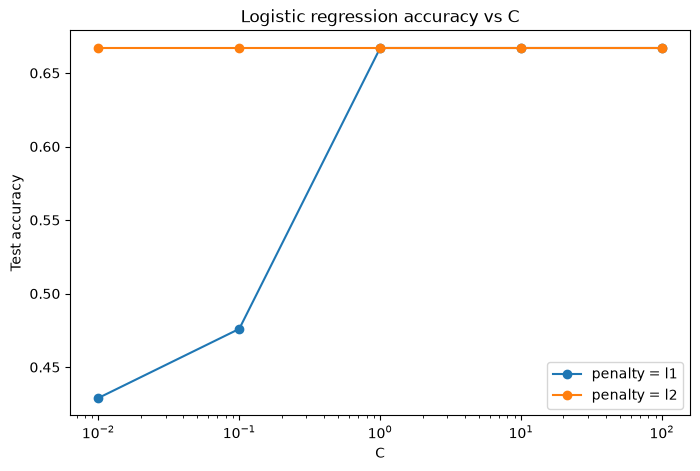

In [9]:
Cs = [0.01, 0.1, 1, 10, 100]
records = []
for penalty in ['l1', 'l2']:
    for C in Cs:
        m = LogisticRegression(penalty=penalty, C=C, solver='saga', max_iter=5000)
        m.fit(Xc_tr_s, yc_tr)
        records.append({'penalty': penalty, 'C': C,
                        'test_accuracy': round(accuracy_score(yc_te, m.predict(Xc_te_s)), 3)})
results = pd.DataFrame(records)
table = results.pivot(index='C', columns='penalty', values='test_accuracy')
print(table)

plt.figure(figsize=(8, 5))
for penalty in ['l1', 'l2']:
    sub = results[results['penalty'] == penalty]
    plt.plot(sub['C'], sub['test_accuracy'], marker='o', label=f'penalty = {penalty}')
plt.xscale('log'); plt.xlabel('C'); plt.ylabel('Test accuracy')
plt.title('Logistic regression accuracy vs C')
plt.legend()
plt.show()

**Discussion.** The dataset is small (67 windows) and imbalanced (the `stable` class is rare),
so accuracy is modest and fluctuates with the hyperparameters. Very small `C` over-regularises and
collapses toward predicting the majority direction; moderate to large `C` lets the model use the
features and gives the best accuracy. `l1` and `l2` behave similarly here, with `l1` additionally
zeroing some coefficients. Overall the previous five days carry only a weak signal about the exact
direction of the next day.

## Part 4 - Clustering

**Hypothesis:** nearby provinces show similar COVID-19 case counts. Cluster the provinces two ways
with k-means - by their daily case series and by their geographic coordinates - then compare.

In [10]:
k = 4
provinces = df['Province'].values
case_matrix = df.drop(columns='Province').values            # 33 x 72

coords = pd.read_csv('coordinates.csv', header=None, names=['Province', 'lat', 'long'])
coords = coords.set_index('Province').loc[provinces].reset_index()   # align to df order

case_labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(case_matrix)
coord_labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(coords[['lat', 'long']].values)

ari = adjusted_rand_score(coord_labels, case_labels)
print('Adjusted Rand index between geographic and case clusterings:', round(ari, 3))

Adjusted Rand index between geographic and case clusterings: -0.015


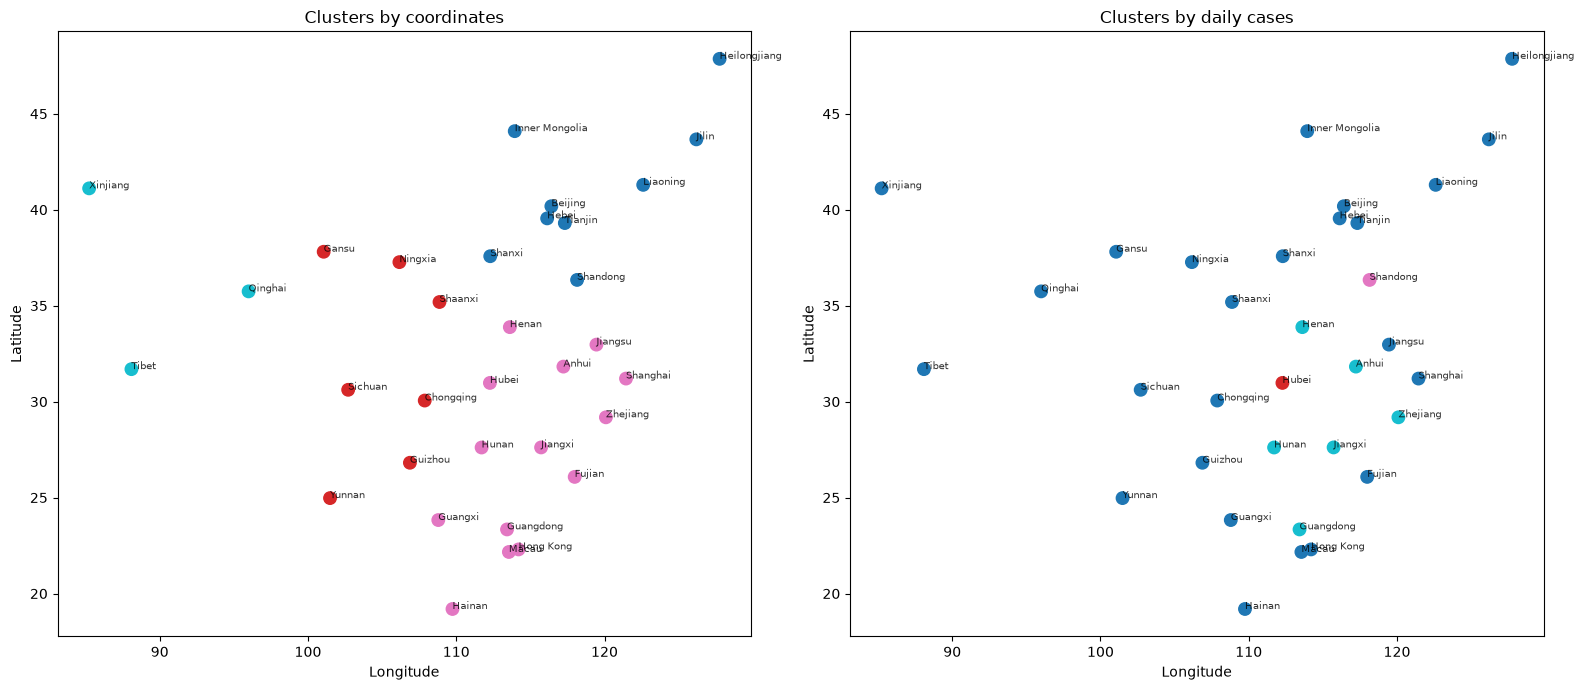

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, labels, title in zip(axes, [coord_labels, case_labels],
                             ['Clusters by coordinates', 'Clusters by daily cases']):
    sc = ax.scatter(coords['long'], coords['lat'], c=labels, cmap='tab10', s=80)
    for _, r in coords.iterrows():
        ax.annotate(r['Province'], (r['long'], r['lat']), fontsize=7, alpha=0.8)
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude'); ax.set_title(title)
plt.tight_layout()
plt.show()

In [12]:
# cross-tabulate the two clusterings
compare = pd.DataFrame({'Province': provinces,
                        'geo_cluster': coord_labels,
                        'case_cluster': case_labels})
print(pd.crosstab(compare['geo_cluster'], compare['case_cluster']))

case_cluster  0  1  2  3
geo_cluster             
0             8  0  1  0
1             7  0  0  0
2             7  1  0  6
3             3  0  0  0


**Discussion.** The adjusted Rand index between the geographic clusters and the case-based
clusters is low, so the two partitions largely disagree. The case clustering is driven by magnitude
(Hubei, the outbreak centre, is separated as essentially its own cluster while most other provinces
fall together because their counts are small), whereas the coordinate clustering only reflects
position on the map. Provinces that are geographic neighbours frequently land in different
case clusters and vice versa. The evidence therefore does **not** support the hypothesis: physical
closeness is a poor predictor of similarity in confirmed-case counts, which depend much more on the
local outbreak size than on distance.